# 🏴‍☠️ AN2DL Challenge 1: Pirate Pain Dataset

## Notebook 01: Exploratory Data Analysis + Preprocessing

This notebook:
1. Loads the dataset,
2. Explores its structure,
3. and prepares the final tensors for model training.

To gain some seconds of life, we will use thread pools for parallel processing where possible (we are HPC pirates after all 🏴‍☠️).

Despite the GIL (Global Interpreter Lock) limitations in Python, we can still achieve some degree of parallelism for I/O-bound tasks and independent computations.
So, yes, it creates the illusion of parallelism, but every second counts when you're a pirate!

Outputs:
- `numpy` arrays:
    - `X_time_train.npy`, `X_time_val.npy`, `X_time_test.npy`: 3D arrays of shape (N, T, F_time) for temporal features.
    - `X_static_train.npy`, `X_static_val.npy`, `X_static_test.npy`: 2D arrays of shape (N, F_static) for static features.
    - `y_train.npy`, `y_val.npy`, `y_test.npy`: 1D arrays of shape (N) for labels.
- Saved scalers, to be used during model inference:
    - `scaler_time.joblib`: `StandardScaler` fitted on temporal features of the training set.
    - `scaler_static.joblib`: `StandardScaler` fitted on static features of the training set.

### 🏴‍☠️ Imports and Paths

In [1]:

import concurrent.futures
import math
import os
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from internal.persistence_manager import PersistenceManager

DATA_DIR = os.path.join('..', 'data')
TRAIN_PATH = os.path.join(DATA_DIR, "pirate_pain_train.csv")
LABELS_PATH = os.path.join(DATA_DIR, "pirate_pain_train_labels.csv")
TEST_PATH = os.path.join(DATA_DIR, "pirate_pain_test.csv")

print("The data directory is set to:", DATA_DIR)
print("Train data path:", TRAIN_PATH)
print("Labels data path:", LABELS_PATH)
print("Test data path:", TEST_PATH)

The data directory is set to: ../data
Train data path: ../data/pirate_pain_train.csv
Labels data path: ../data/pirate_pain_train_labels.csv
Test data path: ../data/pirate_pain_test.csv


### 📥 Data Loading and Initial Exploration

In [2]:
def load_data() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Loads the Pirate Pain Dataset from CSV files.
    Returns:
        pirate_pain_train_df (pd.DataFrame): Training features.
        pirate_pain_train_labels_df (pd.DataFrame): Training labels.
        pirate_pain_test_df (pd.DataFrame): Test features.
    """
    return pd.read_csv(TRAIN_PATH), pd.read_csv(LABELS_PATH), pd.read_csv(TEST_PATH)

pirate_pain_train_df, pirate_pain_train_labels_df, pirate_pain_test_df = load_data()

print("📥 Data Loaded (rows, columns):")
print(f"    ~ 💪 Train shape: {pirate_pain_train_df.shape}")
print(f"    ~ 🏷️ Labels shape: {pirate_pain_train_labels_df.shape}")
print(f"    ~ 🧑‍🏫 Test shape: {pirate_pain_test_df.shape}")
# just to have a look at the data
print("👀 Take me a look at the training data:")
pirate_pain_train_df.head()

📥 Data Loaded (rows, columns):
    ~ 💪 Train shape: (105760, 40)
    ~ 🏷️ Labels shape: (661, 2)
    ~ 🧑‍🏫 Test shape: (211840, 40)
👀 Take me a look at the training data:


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5


### 🔍 Feature Analysis

In [3]:
# Identify all feature columns (exclude id and time columns)
id_col = "sample_index"
time_col = "time"
feature_cols = [c for c in pirate_pain_train_df.columns if c not in [id_col, time_col]]

# Group by sample index to see structure
group_by_id_col = pirate_pain_train_df.groupby(id_col)

# Check sequence length consistency
seq_len = group_by_id_col[time_col].count().unique()
print(f"Unique sequence lengths: {seq_len}. {
    '✅ All sequences have consistent length.'
        if len(seq_len) == 1 else
    '🫤 Sequences have varying lengths!'
}")

# Feature overview
print(f"Total features: {len(feature_cols)}")

static_features: list[str] = []
dynamic_features: list[str] = []

# To identify static vs dynamic, we check the number of unique values per feature within each sample.
# If a feature has only one unique value per sample, it's static; otherwise, it's dynamic (varies over time).
def is_static_feature(_col) -> tuple[str, bool]:
    """
    Checks if a feature column is static (same value for all time steps within a sample).
    :param _col: Feature column name.
    :return: Tuple of (column name, is_static boolean).
    """
    nunique = group_by_id_col[_col].nunique().max()
    return _col, nunique == 1

# Starts a thread pool to check each feature column in parallel
with concurrent.futures.ThreadPoolExecutor() as executor:
    # Map the is_static_feature function to all feature columns, this returns an iterator of results
    for col, is_static in list(executor.map(is_static_feature, feature_cols)):
        if is_static:
            static_features.append(col)
        else:
            dynamic_features.append(col)

print("Static features:", static_features)
print("Dynamic features:", dynamic_features)
print(f"Static: {len(static_features)}, Dynamic: {len(dynamic_features)}")

Unique sequence lengths: [160]. ✅ All sequences have consistent length.
Total features: 38
Static features: ['n_legs', 'n_hands', 'n_eyes', 'joint_30']
Dynamic features: ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29']
Static: 4, Dynamic: 34


### ⚠️ Sanity Checks: NaNs and Outliers

NaNs in train features: 0
NaNs in train labels: 0

Dynamic features describe():
                  count      mean       std           min           25%  \
pain_survey_1  105760.0  1.633746  0.682423  0.000000e+00  2.000000e+00   
pain_survey_2  105760.0  1.654851  0.669639  0.000000e+00  2.000000e+00   
pain_survey_3  105760.0  1.653640  0.666649  0.000000e+00  2.000000e+00   
pain_survey_4  105760.0  1.663134  0.661994  0.000000e+00  2.000000e+00   
joint_00       105760.0  0.943095  0.202051  0.000000e+00  8.282775e-01   
joint_01       105760.0  0.916955  0.197608  0.000000e+00  8.114449e-01   
joint_02       105760.0  0.779296  0.295605  1.015036e-03  5.688500e-01   
joint_03       105760.0  0.767921  0.300787  5.403209e-03  5.200203e-01   
joint_04       105760.0  0.709186  0.418058  0.000000e+00  1.845845e-01   
joint_05       105760.0  0.711306  0.411783  0.000000e+00  2.105514e-01   
joint_06       105760.0  0.875185  0.240900  0.000000e+00  8.391664e-01   
joint_07       10576

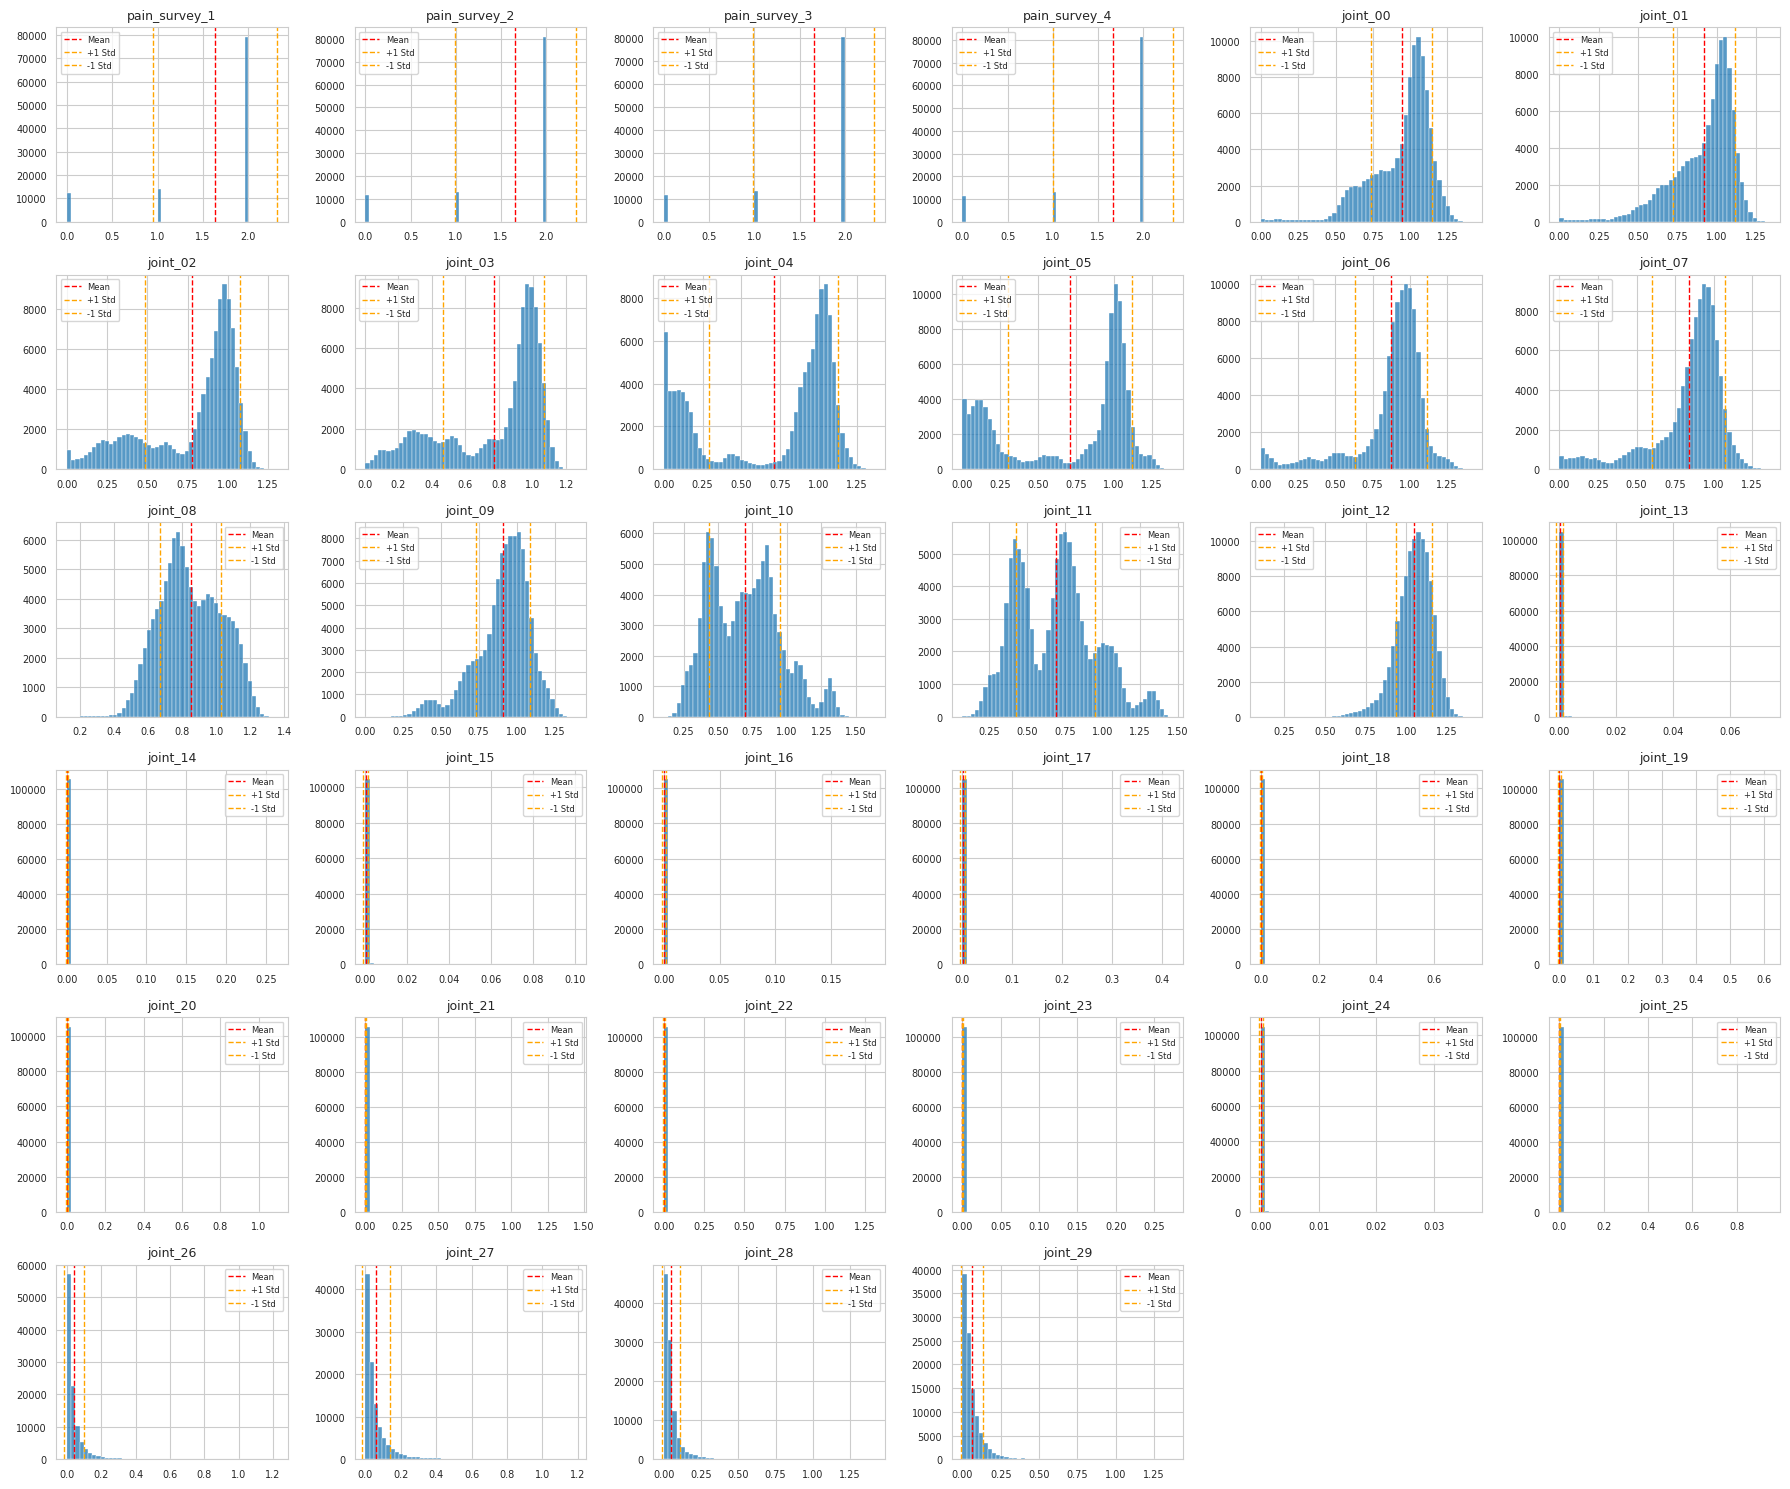

In [4]:
# NaN checks
print(f"NaNs in train features: {pirate_pain_train_df.isna().sum().sum()}")
print(f"NaNs in train labels: {pirate_pain_train_labels_df.isna().sum().sum()}")

# Simple outlier check on dynamic features
dyn_desc = pirate_pain_train_df[dynamic_features].describe().T
print("\nDynamic features describe():")
print(dyn_desc)

def plot_dynamic_features_grid(n_cols=6, bins=50, out_dir: str | None = None) -> str | None:
    """
    Plots histograms of all dynamic features in a grid layout. Each subplot shows the distribution of a dynamic feature,
    along with vertical lines indicating the mean and one standard deviation above and below the mean.

    Args:
        n_cols (int): Number of columns in the grid layout.
        bins (int): Number of bins for the histograms.
        out_dir (str | None): Directory to save the output figure. If None, the figure is not saved.

    Returns:
        str | None: Path to the saved figure if out_dir is provided, otherwise None.
    """
    n = len(dynamic_features)
    n_rows = math.ceil(n / n_cols)
    _fig, _axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
    _axes = _axes.flatten()

    plot_executor = concurrent.futures.ThreadPoolExecutor()

    def plot_feature_hist(_c: str, _ax: plt.Axes):
        sns.histplot(pirate_pain_train_df[_c].dropna(), bins=bins, kde=False, ax=_ax, color="C0")
        _ax.set_title(_c, fontsize=9)
        _ax.set_xlabel("")
        _ax.set_ylabel("")
        _ax.tick_params(axis="both", which="major", labelsize=7)
        # Add lines for mean and std
        mean_val = pirate_pain_train_df[_c].mean()
        std_val = pirate_pain_train_df[_c].std()
        _ax.axvline(mean_val, color="red", linestyle="--", linewidth=1)
        _ax.axvline(mean_val + std_val, color="orange", linestyle="--", linewidth=1)
        _ax.axvline(mean_val - std_val, color="orange", linestyle="--", linewidth=1)
        _ax.legend(["Mean", "+1 Std", "-1 Std"], fontsize=6)

    for i, c in enumerate(dynamic_features):
        ax = _axes[i]
        plot_executor.submit(plot_feature_hist, c, ax)

    # Hide any unused subplots
    for j in range(n, len(_axes)):
        _axes[j].axis("off")

    # Wait for all plots to finish, then shutdown the executor
    plot_executor.shutdown()

    plt.tight_layout()

    # Save the figure if out_dir is provided
    path = None
    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        path = os.path.join(out_dir, f"dynamic_hist_grid_{timestamp}.pdf")
        plt.savefig(path, bbox_inches="tight")
    plt.show()
    plt.close(_fig)
    return path

# image_path = plot_dynamic_features_grid(out_dir="figures")
image_path = plot_dynamic_features_grid()
if image_path is not None:
    print("Saved image to:", image_path)

### 📊 Label Distribution Analysis

The labels are categorical with three classes: `no_pain`, `low_pain`, and `high_pain`.

The distribution of these labels is crucial for understanding class imbalance, which can affect model training.
And this is also suggested by the professor:

> _"Many the healthy, few the sick. If only to the many you listen, the faint whisper of truth never shall you hear."_
>
> Your model, the easy path it chooses: to always predict the common class. Accuracy, an illusion it becomes. Weigh your loss! Give more power to the rare voices. Ensure an error on the 'few' matters more than an error on the 'many'. Only then, the rare class to find will you learn.

From the following plot and counts, we can see that `no_pain` is the most frequent class (77.31%), `low_pain` has 14.22%, and `high_pain` is the least frequent (8.47%).
This imbalance will need to be addressed during model training, possibly through techniques like class weighting or oversampling.

The `n_legs`, `n_hands`, and `n_eyes` features are static, indicating they do not change over time for each sample. BUT their values are written as words instead of numbers, which may require encoding before model training.

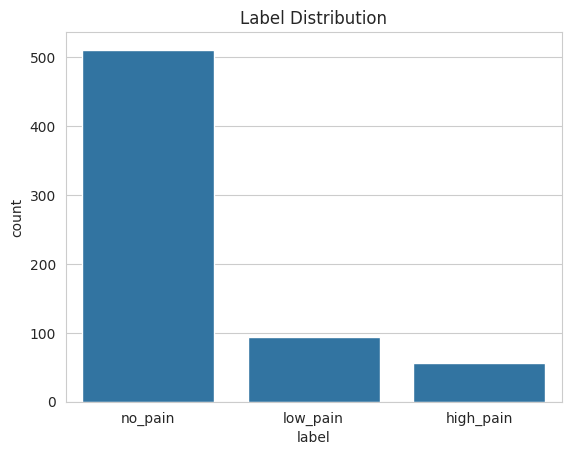

Counts:
label
no_pain      511
low_pain      94
high_pain     56
Name: count, dtype: int64
Label: no_pain, Count: 511, Percentage: 77.31%
Label: low_pain, Count: 94, Percentage: 14.22%
Label: high_pain, Count: 56, Percentage: 8.47%


In [5]:
"""
Label Distribution Visualization
"""
_counts = pirate_pain_train_labels_df["label"].value_counts()
sns.countplot(
    data=pirate_pain_train_labels_df,
    x="label",
    order=_counts.index
)
plt.title("Label Distribution")
plt.show()

print(f"Counts:\n{_counts}")
total_counts = len(pirate_pain_train_labels_df)
for label, count in _counts.items():
    print(f"Label: {label}, Count: {count}, Percentage: {count / total_counts:.2%}")

### 🏴‍☠️ Encoding Static Categorical Features

Here we parse the pirate feature columns to extract numeric counts and prosthetic indicators.

If a value contains the prosthetic word (e.g., `peg_leg`), a binary indicator is created.

For example:
- `n_legs`:
    - `two` -> `n_legs_num` = 2, `has_peg_leg` = 0
    - `one+peg_leg` -> `n_legs_num` = 2, `has_peg_leg` = 1

Indicates the pirate has 2 legs, one of which is a peg leg (prosthetic).

From the results, we can see that only a small fraction of samples has prosthetics:
- Percentage of samples with `has_peg_leg`: 0.90772%
- Percentage of samples with `has_hook_hand`: 0.90772%
- Percentage of samples with `has_eye_patch`: 0.90772%

This might be important to consider during model training, as these features could have a significant impact on the pain levels.

In [6]:
def parse_pirate_feature(df: pd.DataFrame, column: str, prosthetic_word: str):
    """
    Parses pirate feature columns (n_legs, n_hands, n_eyes) to extract numeric counts and prosthetic indicators.

    If a value contains the prosthetic word (e.g., 'peg_leg'), a binary indicator is created.
    The numeric part is extracted from the word representation (e.g., 'two' -> 2).

    Args:
        df (pd.DataFrame): Input dataframe.
        column (str): Column name to parse.
        prosthetic_word (str): Word indicating presence of prosthetic.
    """
    df[column] = df[column].astype(str).str.lower()

    # binary prosthesis indicator
    df[f"has_{prosthetic_word}"] = df[column].str.contains(prosthetic_word).astype(int)

    # numeric conversion
    word_to_num = {
        "none": 0,  # 'cmon, could be possible?
        "one": 1,
        "two": 2,
    }
    # extract the first word before '+' if present
    df[f"{column}_num"] = df[column].str.split("+").str[0].map(word_to_num)

executor = concurrent.futures.ThreadPoolExecutor()

# Apply to both train and test
concurrent.futures.wait([
    executor.submit(parse_pirate_feature, pirate_pain_train_df, "n_legs", "peg_leg"),
    executor.submit(parse_pirate_feature, pirate_pain_train_df, "n_hands", "hook_hand"),
    executor.submit(parse_pirate_feature, pirate_pain_train_df, "n_eyes", "eye_patch"),
    executor.submit(parse_pirate_feature, pirate_pain_test_df, "n_legs", "peg_leg"),
    executor.submit(parse_pirate_feature, pirate_pain_test_df, "n_hands", "hook_hand"),
    executor.submit(parse_pirate_feature, pirate_pain_test_df, "n_eyes", "eye_patch")
])

concurrent.futures.wait([
    # Drop original text columns (replaced by numeric versions)
    executor.submit(pirate_pain_train_df.drop, labels=["n_legs", "n_hands", "n_eyes"], axis=1, inplace=True),
    executor.submit(pirate_pain_test_df.drop, labels=["n_legs", "n_hands", "n_eyes"], axis=1, inplace=True),
    # Print samples with prosthetics
    executor.submit(print, "Samples with peg_leg:\n", pirate_pain_train_df[pirate_pain_train_df["has_peg_leg"] == 1][["n_legs_num", "has_peg_leg"]].drop_duplicates()),
    executor.submit(print, "\nSamples with hook_hand:\n", pirate_pain_train_df[pirate_pain_train_df["has_hook_hand"] == 1][["n_hands_num", "has_hook_hand"]].drop_duplicates()),
    executor.submit(print, "\nSamples with eye_patch:\n", pirate_pain_train_df[pirate_pain_train_df["has_eye_patch"] == 1][["n_eyes_num", "has_eye_patch"]].drop_duplicates())
])

# Check the new size of training data
print("\nUpdated training data shape:", pirate_pain_train_df.shape)
# Show the percentage of samples with prosthetics
total_samples = pirate_pain_train_df[id_col].nunique()
group_by_id_col_updated = pirate_pain_train_df.groupby(id_col)
def print_prosthetic_percentage(prosthetic_col: str) -> None:
    """
    Prints the percentage of samples with a given prosthetic.
    :param prosthetic_col: Prosthetic column name.
    """
    print(f"Percentage of samples with {prosthetic_col}: {
        (group_by_id_col_updated[prosthetic_col].max().sum() / total_samples) * 100
    :.5f}%")
executor.submit(print_prosthetic_percentage, "has_peg_leg")
executor.submit(print_prosthetic_percentage, "has_hook_hand")
executor.submit(print_prosthetic_percentage, "has_eye_patch")

executor.shutdown()

Samples with peg_leg:
       n_legs_num  has_peg_leg
1280           1            1

Samples with hook_hand:
       n_hands_num  has_hook_hand
1280            1              1

Samples with eye_patch:
       n_eyes_num  has_eye_patch
1280           1              1

Updated training data shape: (105760, 43)
Percentage of samples with has_peg_leg: 0.90772%
Percentage of samples with has_hook_hand: 0.90772%
Percentage of samples with has_eye_patch: 0.90772%


### 📊 Visualization: Prosthetics vs Pain Levels

Here we visualize the relationship between the number of legs, hands, and eyes (including prosthetics) and the pain levels.

The plots show the distribution of pain levels for different counts of legs, hands, and eyes.

The analysis reveals that only the `low_pain` and `no_pain` categories include pirates with prosthetics.

Although this is an interesting observation, it could also be a result of the small number of pirates with prosthetics in the dataset.

Finally, we print the counts to confirm the observations from the plots.

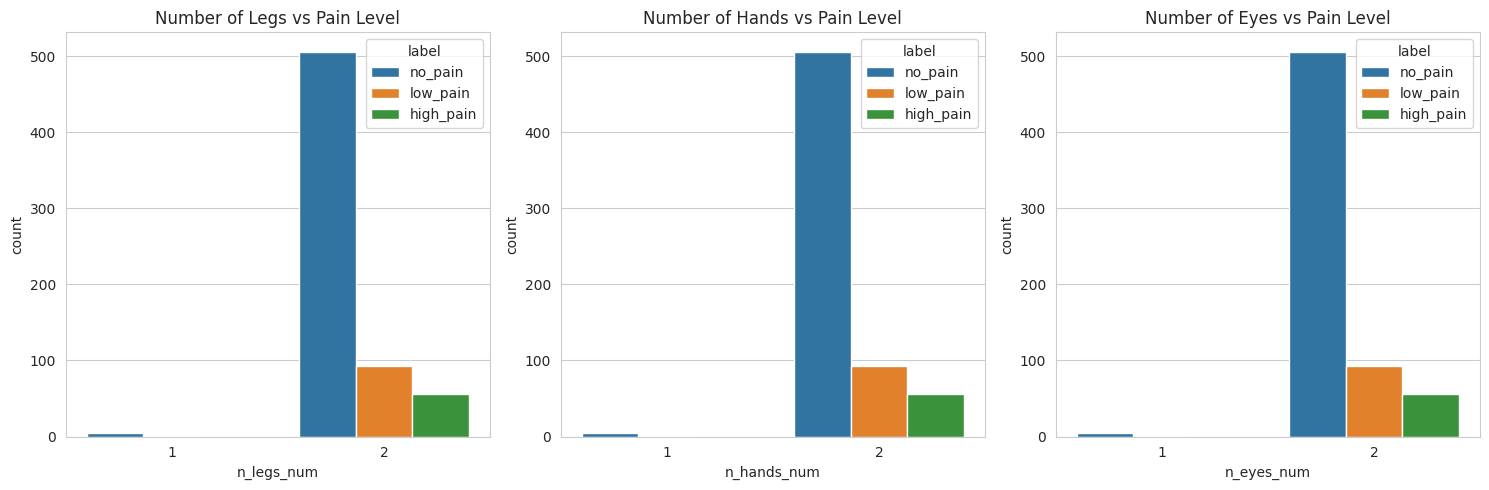


Counts for n_legs_num by pain level:
label       high_pain  low_pain  no_pain
n_legs_num                              
1                   0         1        5
2                  56        93      506

Counts for n_hands_num by pain level:
label        high_pain  low_pain  no_pain
n_hands_num                              
1                    0         1        5
2                   56        93      506

Counts for n_eyes_num by pain level:
label       high_pain  low_pain  no_pain
n_eyes_num                              
1                   0         1        5
2                  56        93      506


In [7]:
# Merge pirate_pain_train_df and pirate_pain_train_labels_df for visualization
merged_df = pd.merge(pirate_pain_train_df[[id_col, "n_legs_num", "n_hands_num", "n_eyes_num"]].drop_duplicates(), pirate_pain_train_labels_df, on=id_col)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.countplot(data=merged_df, x="n_legs_num", hue="label", order=sorted(merged_df["n_legs_num"].unique()))
plt.title("Number of Legs vs Pain Level")
plt.subplot(1, 3, 2)
sns.countplot(data=merged_df, x="n_hands_num", hue="label", order=sorted(merged_df["n_hands_num"].unique()))
plt.title("Number of Hands vs Pain Level")
plt.subplot(1, 3, 3)
sns.countplot(data=merged_df, x="n_eyes_num", hue="label", order=sorted(merged_df["n_eyes_num"].unique()))
plt.title("Number of Eyes vs Pain Level")
plt.tight_layout()
plt.show()
# Never trust plots alone! Let's also print the counts to be sure
for feature in ["n_legs_num", "n_hands_num", "n_eyes_num"]:
    print(f"\nCounts for {feature} by pain level:")
    print(merged_df.groupby([feature, 'label']).size().unstack(fill_value=0))

### 🧮 Create Final Feature Lists

We now define the final feature lists for dynamic and static features, based on our previous analysis.

List explanations:
- `DYN_SURVEYS`: Dynamic survey features (ordinal, not scaled).
- `DYN_JOINTS`: Dynamic joint features (continuous, will be scaled).
- `STATIC_CONT`: Static continuous features (will be scaled).
- `STATIC_BIN`: Static binary features (not scaled).
- `ALL_DYNAMIC`: All dynamic features combined.
- `ALL_STATIC`: All static features combined.
- `SEQ_COLS`: Final columns for sequence data (features + id + time).
- `LABEL_COLS`: Final columns for labels.
- `train_df` and `test_df`: DataFrames containing only the selected columns, sorted by sample index and time.

In [8]:
# keep unscaled (ordinal 0-2)
DYN_SURVEYS = ['pain_survey_1','pain_survey_2','pain_survey_3','pain_survey_4']
# will scale (continuous)
DYN_JOINTS  = [f'joint_{i:02d}' for i in range(30)]
# scale only joint_30
STATIC_CONT = ['n_legs_num','n_hands_num','n_eyes_num','joint_30']
# never scale
STATIC_BIN  = ['has_peg_leg','has_hook_hand','has_eye_patch']

# Final feature lists
ALL_DYNAMIC = DYN_SURVEYS + DYN_JOINTS
ALL_STATIC  = STATIC_CONT + STATIC_BIN

# Final column lists
SEQ_COLS    = ['sample_index','time'] + ALL_STATIC + ALL_DYNAMIC
LABEL_COLS  = ['sample_index','label']

print(f"🏃 Final dynamic features ({len(ALL_DYNAMIC)}): {ALL_DYNAMIC}")
print(f"\n😴 Final static features ({len(ALL_STATIC)}): {ALL_STATIC}")

# Keep only columns we use
train_df = pirate_pain_train_df[SEQ_COLS].copy()
test_df  = pirate_pain_test_df[SEQ_COLS].copy()   # test has no labels

# Sort by (sample_index, time)
train_df = train_df.sort_values(['sample_index','time'])
test_df  = test_df.sort_values(['sample_index','time'])

print("\n👌 Final training data shape:", train_df.shape)
print("👌 Final test data shape:", test_df.shape)


🏃 Final dynamic features (34): ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29']

😴 Final static features (7): ['n_legs_num', 'n_hands_num', 'n_eyes_num', 'joint_30', 'has_peg_leg', 'has_hook_hand', 'has_eye_patch']

👌 Final training data shape: (105760, 43)
👌 Final test data shape: (211840, 43)


In [9]:
print("👀💪 Take me a look at the final training data:")
train_df.head(10)

👀💪 Take me a look at the final training data:


,sample_index,time,n_legs_num,n_hands_num,n_eyes_num,joint_30,has_peg_leg,has_hook_hand,has_eye_patch,pain_survey_1,...,joint_20,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29
0,0,0,2,2,2,0.5,0,0,0,2,...,6.140248e-07,3.499558e-06,1.945042e-06,3.999558e-06,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815
1,0,1,2,2,2,0.5,0,0,0,2,...,1.931978e-06,3.976952e-07,6.765107e-07,6.019627e-06,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716
2,0,2,2,2,2,0.5,0,0,0,2,...,5.730838e-07,1.533820e-07,1.698525e-07,1.446051e-06,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105
3,0,3,2,2,2,0.5,0,0,0,2,...,3.677486e-05,1.006865e-05,5.511079e-07,1.847597e-06,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648
4,0,4,2,2,2,0.5,0,0,0,2,...,2.037939e-05,4.437266e-06,1.735459e-07,1.552722e-06,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328
5,0,5,2,2,2,0.5,0,0,0,2,...,2.060783e-05,1.073167e-06,1.753837e-07,2.957340e-07,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767
6,0,6,2,2,2,0.5,0,0,0,2,...,2.038030e-05,1.074800e-06,1.772156e-07,1.976558e-06,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056
7,0,7,2,2,2,0.5,0,0,0,2,...,4.703305e-07,8.829074e-07,1.790415e-07,2.210562e-06,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732
8,0,8,2,2,2,0.5,0,0,0,2,...,4.984277e-05,1.621055e-06,1.165161e-06,3.030164e-07,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257
9,0,9,2,2,2,0.5,0,0,0,0,...,5.350527e-05,1.609114e-06,3.959558e-06,2.017157e-06,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966


In [10]:
print("👀🧑‍🏫 Take me a look at the final test data:")
test_df.head(10)

👀🧑‍🏫 Take me a look at the final test data:


,sample_index,time,n_legs_num,n_hands_num,n_eyes_num,joint_30,has_peg_leg,has_hook_hand,has_eye_patch,pain_survey_1,...,joint_20,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29
0,0,0,2,2,2,0.5,0,0,0,2,...,0.000031,0.000003,0.000004,0.000003,0.000003,0.000068,0.019372,0.066324,0.022228,0.013576
1,0,1,2,2,2,0.5,0,0,0,2,...,0.000031,0.000003,0.000004,0.000004,0.000003,0.000029,0.069747,0.080417,0.023650,0.038793
2,0,2,2,2,2,0.5,0,0,0,2,...,0.000048,0.000006,0.000004,0.000009,0.000004,0.000008,0.054968,0.058811,0.027023,0.054202
3,0,3,2,2,2,0.5,0,0,0,1,...,0.000031,0.000005,0.000004,0.000003,0.000004,0.000015,0.048695,0.047128,0.016151,0.024983
4,0,4,2,2,2,0.5,0,0,0,2,...,0.000045,0.000006,0.000004,0.000003,0.000003,0.000008,0.019762,0.031116,0.015618,0.017931
5,0,5,2,2,2,0.5,0,0,0,2,...,0.000033,0.000006,0.000003,0.000004,0.000003,0.000014,0.037433,0.034157,0.013880,0.033762
6,0,6,2,2,2,0.5,0,0,0,2,...,0.000031,0.000005,0.000003,0.000007,0.000003,0.000018,0.076399,0.025877,0.049272,0.037960
7,0,7,2,2,2,0.5,0,0,0,2,...,0.000041,0.000003,0.000003,0.000004,0.000005,0.000070,0.041566,0.055916,0.024414,0.026338
8,0,8,2,2,2,0.5,0,0,0,2,...,0.000046,0.000003,0.000007,0.000004,0.000004,0.000050,0.040049,0.047536,0.018454,0.010675
9,0,9,2,2,2,0.5,0,0,0,2,...,0.000046,0.000003,0.000003,0.000005,0.000002,0.000017,0.022977,0.096785,0.035494,0.023898


#### 🔧 Scaling Dynamic and Static Features

The dynamic joint features (`joint_00` to `joint_29`) will be scaled using `StandardScaler`, which standardizes features by removing the mean and scaling to unit variance. The standard score of a sample $x$ is calculated as:

$$ z = \frac{(x - \mu)}{\sigma} $$

where $\mu$ is the mean of the training samples and $\sigma$ is the standard deviation of the training samples. This scaling is done to ensure that the model training is not biased towards features with larger scales (mean goes to 0, std goes to 1).

In addition, the static feature `joint_30` will also be scaled using a separate `StandardScaler` because it is a static feature. However, we need to ensure that we fit the scaler only on one value per sample, since it does not vary over time. Hence, we will extract one row per sample from the training data to fit the scaler.

In [11]:
# Create scalers to fit on train data
scaler_dyn = StandardScaler()
scaler_sta = StandardScaler()

# Dynamic joints, fit per-feature across all rows (all samples * time)
scaler_dyn.fit(train_df[DYN_JOINTS].values)

# Static joints
# We must fit joint_30 per-sample static value. Extract one row per sample from train:
one_row_per_sample = train_df.groupby('sample_index', as_index=False).head(1)
scaler_sta.fit(one_row_per_sample[['joint_30']].values)


,copy,True
,with_mean,True
,with_std,True


### 🧬 Transform Data

Scale the dynamic joint features in both training and test sets using the fitted scaler.

In [12]:
# Dynamic joints
train_df.loc[:, DYN_JOINTS] = scaler_dyn.transform(train_df[DYN_JOINTS].values)
test_df.loc[:,  DYN_JOINTS] = scaler_dyn.transform(test_df[DYN_JOINTS].values)

### 🛠️ Build `numpy` Arrays

In this step, we will convert the processed DataFrames into `numpy` arrays suitable for model training.

We will create:
- `X_dyn_tr`: 3D array of shape (N, T, D_dyn) for dynamic features in the training set.
- `X_sta_tr`: 2D array of shape (N, D_sta) for static features in the training set.
- `y_tr`: 1D array of shape (N) for labels in the training set.
- `X_dyn_te`: 3D array of shape (N, T, D_dyn) for dynamic features in the test set.
- `X_sta_te`: 2D array of shape (N, D_sta) for static features in the test set.

In [13]:
def build_arrays(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Builds numpy arrays for dynamic and static features from the dataframe.
    Dynamic features are stacked into a 3D array (N, T, D_dyn).
    Static features are extracted as a 2D array (N, D_sta).
    :param df: Input dataframe.
    :return: Tuple of (X_dyn, X_static, sample_ids).
    """
    # ~ dynamic (T, D_dyn)
    dyn = (df
           .groupby('sample_index', sort=True)[ALL_DYNAMIC] # group by sample_index
           .apply(lambda g: g.to_numpy(dtype=np.float32))   # convert each group to numpy array
           .to_list())

    # ~ static (D_sta)
    sta = (df
           .groupby('sample_index', sort=True)[ALL_STATIC]  # again, group by sample_index
           .head(1)                                         # take first row per sample
           .reset_index(drop=True))                         # reset index for clean access

    # scale joint_30 now (why now? because we need one row per sample)
    sta = sta.copy()
    sta.loc[:, ['joint_30']] = scaler_sta.transform(sta[['joint_30']].values)

    return (
        np.stack(dyn, axis=0),  # (N, T, D_dyn)
        sta.to_numpy(dtype=np.float32), # (N, D_sta)
        ( # (N,) sample indices
            df
            .groupby('sample_index', sort=True) # group by sample_index
            .size()                             # get size to keep the index
            .reset_index()['sample_index']      # reset index and extract sample_index
            .to_numpy()                         # again, to numpy
        )
    )

# Build arrays for train and test
X_dyn_tr, X_sta_tr, ids_tr = build_arrays(train_df)
X_dyn_te, X_sta_te, ids_te = build_arrays(test_df)

# Labels aligned to ids_tr (we need to map string labels to integers)
label_map = {'no_pain': 0, 'low_pain': 1, 'high_pain': 2}
labels_df_sorted = pirate_pain_train_labels_df.set_index('sample_index').loc[ids_tr]
y_tr = labels_df_sorted['label'].map(label_map).to_numpy(dtype=np.int64)

# Print shapes
print(f"Final array shapes:")
print("  Train dynamic:", X_dyn_tr.shape)
print("  Train static: ", X_sta_tr.shape)
print("  Train labels: ", y_tr.shape)
print("  Test dynamic: ", X_dyn_te.shape)
print("  Test static:  ", X_sta_te.shape)

Final array shapes:
  Train dynamic: (661, 160, 34)
  Train static:  (661, 7)
  Train labels:  (661,)
  Test dynamic:  (1324, 160, 34)
  Test static:   (1324, 7)


### 🚦 Train/Validation Split

Here we perform a stratified split of the training data into training and validation sets.

We use `StratifiedKFold` from `sklearn.model_selection` to ensure that the class distribution is maintained in both sets.

The split is done with 5 folds, and we take the first fold as our validation set.

We choose to shuffle the data before splitting to ensure randomness, and we set a random seed for reproducibility.

The number of splits is set to 5, since the dataset is not very large, and this allows us to have a reasonable size for both training and validation sets while maintaining class balance.

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(skf.split(np.zeros_like(y_tr), y_tr))

X_dyn_train, X_sta_train, y_train = X_dyn_tr[train_idx], X_sta_tr[train_idx], y_tr[train_idx]
X_dyn_val,   X_sta_val,   y_val   = X_dyn_tr[val_idx],   X_sta_tr[val_idx],   y_tr[val_idx]

print("Train shapes:", X_dyn_train.shape, X_sta_train.shape, y_train.shape)
print("Val shapes:  ", X_dyn_val.shape,   X_sta_val.shape,   y_val.shape)

Train shapes: (528, 160, 34) (528, 7) (528,)
Val shapes:   (133, 160, 34) (133, 7) (133,)


### ⚖️ Compute Class Weights

To address class imbalance in the training data, we compute class weights using `compute_class_weight` from `sklearn.utils.class_weight`.

These weights can be used during model training to give more importance to minority classes, helping the model to learn better representations for them.

Finally, we print the computed class weights for each class.

In [15]:
classes = np.array([0,1,2])
w = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = w.astype(np.float32)
print(dict(zip(classes, class_weights)))

{np.int64(0): np.float32(0.43137255), np.int64(1): np.float32(2.3157895), np.int64(2): np.float32(4.0)}


### 💾 Save Processed Arrays and Scalers

We save all the processed numpy arrays and fitted scalers into a single `joblib` file for easy loading during model training and inference.

This includes:
- `X_dyn_train`, `X_sta_train`, `y_train`: Training data.
- `X_dyn_val`, `X_sta_val`, `y_val`: Validation data.
- `X_dyn_test`, `X_sta_test`, `ids_test`: Test data.
- `class_weights`: Computed class weights.
- `scaler_dyn`, `scaler_sta`: Fitted scalers for dynamic and static features.
- `label_map`: Mapping of string labels to integers (just in case we need it later).

We use the `PersistenceManager` utility to handle the saving process.

In [16]:
PersistenceManager.save_arrays_and_scalers({
    'X_dyn_train': X_dyn_train,
    'X_sta_train': X_sta_train,
    'y_train': y_train,
    'X_dyn_val': X_dyn_val,
    'X_sta_val': X_sta_val,
    'y_val': y_val,
    'X_dyn_test': X_dyn_te,
    'X_sta_test': X_sta_te,
    'ids_test': ids_te,
    'class_weights': class_weights,
    'scaler_dyn': scaler_dyn,
    'scaler_sta': scaler_sta,
    'label_map': label_map
})

Arrays and scalers saved successfully to: /home/andre/university/AN2DL-Challenge-1/notebooks/processed/arrays_and_scalers.joblib
